<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/process/digital_twin_model_vs_measurement.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Digital Twin Model vs Measurement

Use synthetic plant measurements to compare a NeqSim process model against measured outlet pressure and compressor power.


## Setup

Install imports and create helper functions.


In [1]:
# Install NeqSim when running in a fresh Colab session.
try:
    import neqsim
except ImportError:
    %pip install neqsim

import json
import pandas as pd
import matplotlib.pyplot as plt
try:
    from neqsim import jneqsim
except ImportError:
    from neqsim import jNeqSim as jneqsim
from neqsim.thermo import TPflash

SystemSrkEos = jneqsim.thermo.system.SystemSrkEos
Stream = jneqsim.process.equipment.stream.Stream
ProcessSystem = jneqsim.process.processmodel.ProcessSystem

def make_gas(temperature_c=25.0, pressure_bara=60.0):
    fluid = SystemSrkEos(273.15 + temperature_c, pressure_bara)
    fluid.addComponent("nitrogen", 0.01)
    fluid.addComponent("CO2", 0.02)
    fluid.addComponent("methane", 0.86)
    fluid.addComponent("ethane", 0.07)
    fluid.addComponent("propane", 0.03)
    fluid.addComponent("n-butane", 0.01)
    fluid.setMixingRule("classic")
    TPflash(fluid)
    fluid.initProperties()
    return fluid


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.4/52.4 MB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 438.5/438.5 kB 15.8 MB/s eta 0:00:00


## Create Synthetic Measurements

The data imitates a few operating points from a compressor package.


In [2]:
measurements = pd.DataFrame({
    "flow_kg_per_hr": [7000, 8500, 10000, 11500],
    "suction_pressure_bara": [48, 50, 52, 53],
    "discharge_pressure_bara": [95, 98, 102, 106],
    "measured_power_kW": [880, 990, 1135, 1280],
})
measurements


,flow_kg_per_hr,suction_pressure_bara,discharge_pressure_bara,measured_power_kW
0,7000,48,95,880
1,8500,50,98,990
2,10000,52,102,1135
3,11500,53,106,1280


## Run the NeqSim Model

For each measurement row, set the model boundary conditions and compute compressor power.


In [3]:
Compressor = jneqsim.process.equipment.compressor.Compressor
rows = []
for _, row in measurements.iterrows():
    fluid = make_gas(25.0, float(row.suction_pressure_bara))
    feed = Stream("Feed gas", fluid)
    feed.setFlowRate(float(row.flow_kg_per_hr), "kg/hr")
    compressor = Compressor("Compressor", feed)
    compressor.setOutletPressure(float(row.discharge_pressure_bara))
    process = ProcessSystem()
    process.add(feed)
    process.add(compressor)
    process.run()
    rows.append({**row.to_dict(), "simulated_power_kW": compressor.getPower("kW")})
comparison = pd.DataFrame(rows)
comparison["residual_kW"] = comparison["measured_power_kW"] - comparison["simulated_power_kW"]
comparison


,flow_kg_per_hr,suction_pressure_bara,discharge_pressure_bara,measured_power_kW,simulated_power_kW,residual_kW
0,7000,48,95,880,169.104373,710.895627
1,8500,50,98,990,201.444473,788.555527
2,10000,52,102,1135,236.496871,898.503129
3,11500,53,106,1280,280.136677,999.863323


## Plot Residuals

Residual plots are a quick digital-twin diagnostic.


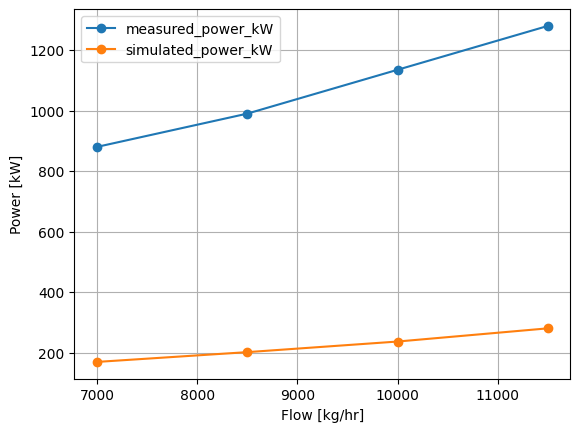

In [4]:
ax = comparison.plot(x="flow_kg_per_hr", y=["measured_power_kW", "simulated_power_kW"], marker="o")
ax.set_xlabel("Flow [kg/hr]")
ax.set_ylabel("Power [kW]")
ax.grid(True)
plt.show()
